In [ ]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [ ]:
# Mounting GoogleDrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Reading data file from GoogleDrive
df = pd.read_pickle("/content/drive/My Drive/Team Project X-Rays/Dataframes/df_basic_1.4.pkl")
df.head()

,Name,Case,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
0,COVID-3563,COVID,1,0,0,0,0,0,0,0,...,191,182,167,158,136,104,66,40,1,132
1,COVID-933,COVID,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,COVID-2646,COVID,61,15,6,4,3,3,3,3,...,235,234,234,230,224,216,213,209,210,204
3,COVID-3508,COVID,23,12,8,16,6,5,5,3,...,229,230,224,222,182,158,149,120,86,9
4,COVID-1165,COVID,101,110,100,27,26,24,34,37,...,203,215,214,212,209,204,192,184,184,171


In [ ]:
#Creating categorical variable from Case
df["Case"] = df.Case.replace({"Normal": 0, "COVID": 1, "Lung_Opacity": 2, "Viral Pneumonia": 3})
df.Case.astype(int)

#Checking construction
print(df.Case.value_counts())

#Splitting data into target and features
target = df.Case
data = df.drop(["Name", "Case"], axis = 1)

data.head()
data.shape

#Splitting data into training and Test sets, save random state
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.2, random_state = 123)

Case
0    10191
2     6012
1     3564
3     1338
Name: count, dtype: int64


In [ ]:
#Standard scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Extracting subsample for hyperparameter tuning
X_subsample, _, y_subsample, _ = train_test_split(X_train, y_train, test_size=0.8, stratify=y_train, random_state = 42)

print(y_subsample.value_counts())

Case
0    1617
2     969
1     577
3     213
Name: count, dtype: int64


In [ ]:
#Defining the models
svm_model = SVC()
knn_model = KNeighborsClassifier()
xgb_model = XGBClassifier(use_label_encoder = False, eval_metric = 'mlogloss')

In [ ]:
#Defining hyperparameters for grid search

#C: Controls the trade-off between achieving a low training error and a low testing error; Low C (e.g., 0.1): Higher regularization, simpler decision boundary,
#possibly underfitting; High C (e.g., 10): Lower regularization, more complex decision boundary, possibly overfitting.
#High C (e.g., 10): Lower regularization, more complex decision boundary, possibly overfitting.
#kernel: Determines the type of transformation applied to the input data. It defines how the input space is mapped into higher-dimensional feature spaces to
#make it possible to perform linear separation; linear: No transformation; uses the data as is; rbf (Radial Basis Function): Maps data into an infinite-dimensional
#space, allowing for complex boundaries.
#gamma: Defines how far the influence of a single training example reaches. Low values mean ‘far’ and high values mean ‘close’; scale: Uses 1 / (n_features * X.var())
#as the value of gamma; auto: Uses 1 / n_features as the value of gamma.

svm_params = {
    #Regularization
    'C': [0.1, 1, 10],
     #Kernels
    'kernel': ['linear', 'rbf'],
    #Kernel coefficient
    'gamma': ['scale', 'auto']
}

#n_neighbors: Specifies the number of neighboring points to consider when making a prediction;
#Low Values (e.g., 3): Model considers fewer neighbors, leading to more complex boundaries, potentially overfitting.
#High Values (e.g., 7): Model considers more neighbors, leading to smoother boundaries, potentially underfitting.
#weights: Determines how each neighbor contributes to the prediction; uniform: All neighbors contribute equally.
#distance: Closer neighbors contribute more significantly than distant ones, with contributions weighted by the inverse of their distance.
#metric: The distance metric used to calculate the distance between points; euclidean: Straight-line distance between two points in Euclidean space.
#minkowski: Generalization of Euclidean and Manhattan distances. (When p=2, it's equivalent to Euclidean; when p=1, it's equivalent to Manhattan.)

knn_params = {
    #Number of neighbors
    'n_neighbors': [3, 5, 7],
    #Weight function
    'weights': ['uniform', 'distance'],
    #Distance metric
    'metric': ['euclidean', 'minkowski']
}

#n_estimators (Number of Boosting Rounds): Determines the number of trees (weak learners) to be added. More trees can capture more complex patterns but also increase
#the risk of overfitting, Lower Values (e.g., 50): Less complex model, faster training, potentially underfitting. #Higher Values (e.g., 100): More complex model, longer
#training time, potentially overfitting.
#max_depth (Maximum Tree Depth): Specifies the maximum depth of each decision tree. Controls the complexity of the model; Lower Values (e.g., 3): Simpler trees, less
#prone to overfitting, might underfit; Higher Values (e.g., 5): More complex trees, can capture more intricate patterns, might overfit.
#learning_rate (Shrinkage): Determines the step size shrinkage used in updating the weights. Smaller values make the model more robust to overfitting but require more
#trees: Lower Values (e.g., 0.1): Slower learning, may need more trees, can generalize better; Higher Values (e.g., 0.2): Faster learning, fewer trees needed, might
#overfit.
#subsample: Represents the fraction of the training samples to be used for fitting the individual base learners. It introduces randomness and can prevent overfitting;
#Lower Values (e.g., 0.8): More randomness, can reduce overfitting, might underfit if too low.
#Higher Values (e.g., 1.0): Less randomness, model uses all samples, might overfit.
#colsample_bytree: Denotes the subsample ratio of columns when constructing each tree. Like subsample, it adds randomness but at the feature level.
#Lower Values (e.g., 0.8): More randomness in feature selection, can reduce overfitting.
#Higher Values (e.g., 1.0): Uses all features, might overfit.

xgb_params = {
    #Number of boosting rounds
    'n_estimators': [50, 100],
    #Maximum tree depth
    'max_depth': [3, 5],
    #Learning rate
    'learning_rate': [0.1, 0.2],
    #Subsample ratio of training instances
    'subsample': [0.8, 1.0],
    #Subsample ratio of columns when constructing each tree
    'colsample_bytree': [0.8, 1.0]
}


In [ ]:
#Setting up and applying grid search - SVM

import time
start_time = time.time()

#cv: Number of cross-validation folds (5 in this case); scoring: Metric for evaluating model performance ('accuracy').
#n_jobs: Number of parallel jobs (using all available cores here); verbose: Level of detail in output during the search (more detailed output with verbose=2).
svm_grid_search = GridSearchCV(svm_model, svm_params, cv = 5, scoring = 'accuracy', n_jobs = -1, verbose = 2)
svm_grid_search.fit(X_subsample, y_subsample)

#Measuring time
model1_time = (time.time() - start_time)/60
model1_time

Fitting 5 folds for each of 12 candidates, totalling 60 fits


26.112185684839883

In [ ]:
model1_time

26.112185684839883

In [ ]:
#Model evaluations - SVM

best_svm_model = svm_grid_search.best_estimator_
print(svm_grid_search.best_estimator_)
y_pred_svm = best_svm_model.predict(X_test)
f1_svm = f1_score(y_test, y_pred_svm, average = 'weighted')
print("SVM F1 Score (Weighted):", f1_svm)
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVC(C=10)
SVM F1 Score (Weighted): 0.8206665688523433

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.86      2103
           1       0.79      0.66      0.72       681
           2       0.81      0.74      0.78      1165
           3       0.93      0.92      0.92       272

    accuracy                           0.82      4221
   macro avg       0.84      0.81      0.82      4221
weighted avg       0.82      0.82      0.82      4221



In [ ]:
#Setting up and applying grid search - KNN

import time
start_time = time.time()

#cv: Number of cross-validation folds (5 in this case); scoring: Metric for evaluating model performance ('accuracy').
#n_jobs: Number of parallel jobs (using all available cores here); verbose: Level of detail in output during the search (more detailed output with verbose=2).
knn_grid_search = GridSearchCV(knn_model, knn_params, cv = 5, scoring = 'accuracy', n_jobs = -1, verbose = 2)
knn_grid_search.fit(X_subsample, y_subsample)

#Measuring time
model1_time = (time.time() - start_time)/60

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [ ]:
model1_time

1.0024558226267497

In [ ]:
#Model evaluations - KNN

best_knn_model = knn_grid_search.best_estimator_
print(knn_grid_search.best_estimator_)
y_pred_knn = best_knn_model.predict(X_test)
f1_knn = f1_score(y_test, y_pred_knn, average = 'weighted')
print("KNN F1 Score (Weighted):", f1_knn)
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))

KNeighborsClassifier(metric='euclidean', n_neighbors=7, weights='distance')
KNN F1 Score (Weighted): 0.7556044694668487

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83      2103
           1       0.68      0.50      0.58       681
           2       0.69      0.75      0.72      1165
           3       0.80      0.81      0.80       272

    accuracy                           0.76      4221
   macro avg       0.75      0.72      0.73      4221
weighted avg       0.76      0.76      0.76      4221



In [ ]:
#Setting up and applying grid search - XGB

import time
start_time = time.time()

#cv: Number of cross-validation folds (5 in this case); scoring: Metric for evaluating model performance ('accuracy').
#n_jobs: Number of parallel jobs (using all available cores here); verbose: Level of detail in output during the search (more detailed output with verbose=2).
xgb_grid_search = GridSearchCV(xgb_model, xgb_params, cv = 5, scoring = 'accuracy', n_jobs = -1, verbose = 2)
xgb_grid_search.fit(X_subsample, y_subsample)

#Measuring time
model1_time = (time.time() - start_time)/60

Fitting 5 folds for each of 32 candidates, totalling 160 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:18:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
model1_time

67.16177716652552

In [ ]:
#Model evaluations - GBC

best_xgb_model = xgb_grid_search.best_estimator_
print(xgb_grid_search.best_estimator_)
y_pred_xgb = best_xgb_model.predict(X_test)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
print("Gradient Boosting F1 Score (Weighted):", f1_xgb)
print("\nGradient Boosting Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)
Gradient Boosting F1 Score (Weighted): 0.826604066493191

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      2103
           1       0.87 

In [ ]:
#Setting up stratifiedKFold
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
#Defining models with their best hyperparameters

#SVM
svm_best = SVC(C = 10, kernel = 'rbf', gamma = 'scale')

#KNN
knn_best = KNeighborsClassifier(n_neighbors = 7, weights = 'distance', metric = 'euclidean')

#XGB
xgb_best = XGBClassifier(n_estimators = 50, max_depth = 5, learning_rate = 0.1, subsample = 0.8,
                         colsample_bytree = 1.0, use_label_encoder = False, eval_metric = 'mlogloss')

In [ ]:
#Calculating cross-validation scores

#SVM
svm_scores = cross_val_score(svm_best, X_train, y_train, cv = stratified_kfold)

#KNN
knn_scores = cross_val_score(knn_best, X_train, y_train, cv = stratified_kfold)

#XGB
xgb_scores = cross_val_score(xgb_best, X_train, y_train, cv = stratified_kfold)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [15:00:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [15:02:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [15:03:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [15:05:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [15:07:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

In [ ]:
#Calculating mean and standard deviation for each model

#SVM
svm_mean = np.mean(svm_scores)
svm_std = np.std(svm_scores)

#KNN
knn_mean = np.mean(knn_scores)
knn_std = np.std(knn_scores)

#XGB
xgb_mean = np.mean(xgb_scores)
xgb_std = np.std(xgb_scores)

In [ ]:
#Printing results
print(f"SVM Mean Accuracy: {svm_mean:.4f}, Standard Deviation: {svm_std:.4f}")
print(f"KNN Mean Accuracy: {knn_mean:.4f}, Standard Deviation: {knn_std:.4f}")
print(f"XGBoost Mean Accuracy: {xgb_mean:.4f}, Standard Deviation: {xgb_std:.4f}")

SVM Mean Accuracy: 0.8571, Standard Deviation: 0.0037
KNN Mean Accuracy: 0.7899, Standard Deviation: 0.0019
XGBoost Mean Accuracy: 0.8201, Standard Deviation: 0.0029


In [ ]:
#Fitting best model
svm_best.fit(X_train, y_train)

SVC(C=10)

In [ ]:
#Predicting on the test set
y_pred = svm_best.predict(X_test)

#Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

#Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.8725
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      2103
           1       0.86      0.83      0.84       681
           2       0.85      0.81      0.83      1165
           3       0.94      0.93      0.93       272

    accuracy                           0.87      4221
   macro avg       0.88      0.87      0.88      4221
weighted avg       0.87      0.87      0.87      4221

Confusion Matrix:
[[1929   44  120   10]
 [  73  563   41    4]
 [ 182   41  939    3]
 [  10    6    4  252]]


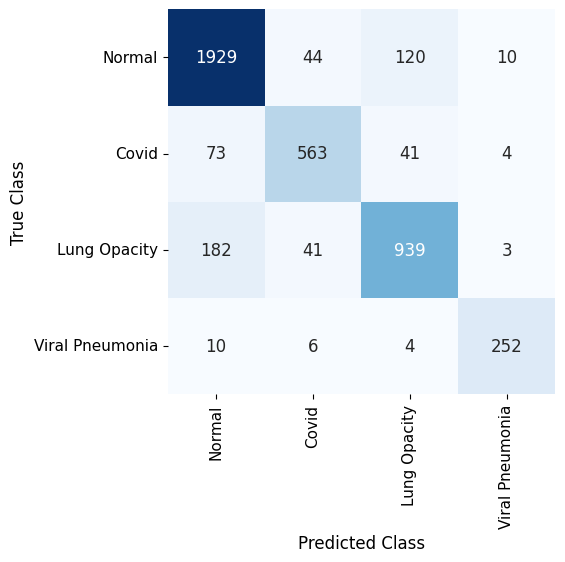

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Confusion matrix
cm = np.array([[1929, 44, 120, 10],
               [73, 563, 41, 4],
               [182, 41, 939, 3],
               [10, 6, 4, 252]])

#Labelling classes
labels = ['Normal', 'Covid', 'Lung Opacity', 'Viral Pneumonia']

#Plotting the confusion matrix
plt.figure(figsize=(5, 5))
heatmap = sns.heatmap(cm, annot = True, fmt = 'g', cmap = 'Blues', xticklabels = labels, yticklabels = labels, annot_kws={"size": 12}, cbar=False)

plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

In [ ]:
xgb_best = XGBClassifier(use_label_encoder = False, eval_metric = 'mlogloss', n_estimators = 100, max_depth = 5, learning_rate = 0.2, subsample = 1.0, colsample_bytree = 1.0)
#Fitting best model
xgb_best.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [22:40:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
#Predicting on the test set
y_pred = xgb_best.predict(X_test)

#Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

#Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.8669
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      2103
           1       0.91      0.80      0.85       681
           2       0.83      0.81      0.82      1165
           3       0.92      0.86      0.89       272

    accuracy                           0.87      4221
   macro avg       0.88      0.85      0.86      4221
weighted avg       0.87      0.87      0.87      4221

Confusion Matrix:
[[1943   16  130   14]
 [  81  544   52    4]
 [ 199   27  938    1]
 [  22   12    4  234]]


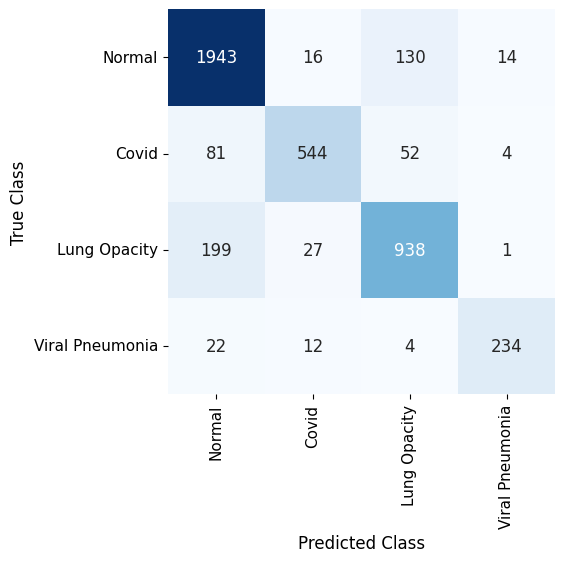

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Confusion matrix
cm = np.array([[1943, 16, 130, 14],
               [81, 544, 52, 4],
               [199, 27, 938, 1],
               [22, 12, 4, 234]])

#Labelling classes
labels = ['Normal', 'Covid', 'Lung Opacity', 'Viral Pneumonia']

#Plotting the confusion matrix
plt.figure(figsize=(5, 5))
heatmap = sns.heatmap(cm, annot = True, fmt = 'g', cmap = 'Blues', xticklabels = labels, yticklabels = labels, annot_kws={"size": 12}, cbar=False)

plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()